In [84]:
import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.cosmology import Planck15
import astropy.cosmology as cosmo
import astropy.units as u
from scipy.optimize import minimize
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
from scipy import integrate
import pandas as pd
plt.style.use(['science','grid','notebook'])
from tqdm import tqdm
color_map='YlGnBu'

In [125]:
### writing the functions for various order assuming Omega_k=0
def z_series_1(z, H0):

    a0 = 1.0
    
    return 300000 * z / H0 * a0
def z_series_2(z, H0, q0):

    a0 = 1.0
    a1 = 1.0/2.0 - q0/2.0
    
    return 300000 * z / H0 * (a0 + a1*z )

def z_series_3(z, H0, q0, j0):

    a0 = 1.0
    a1 = 1.0/2.0 - q0/2.0
    a2 = -1.0/6.0 - j0/6.0 + q0/6.0 + q0**2.0 / 2.0
    
    return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0)

def z_series_4(z, H0, q0, j0, s0):

    a0 = 1.0
    a1 = 1.0/2.0 - q0/2.0
    a2 = -1.0/6.0 - j0/6.0 + q0/6.0 + q0**2.0 / 2.0
    a3 = 1.0/12.0 + 5 * j0 / 24.0 - q0/12.0 + 5.0*j0*q0/12.0  -5.0 * q0**2.0 / 8.0  -5.0 * q0**3.0 / 8.0 + s0/24.0

    return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0)

def z_series_4(z, H0, q0, j0, s0):

    a0 = 1.0
    a1 = 1.0/2.0 - q0/2.0
    a2 = -1.0/6.0 - j0/6.0 + q0/6.0 + q0**2.0 / 2.0
    a3 = 1.0/12.0 + 5 * j0 / 24.0 - q0/12.0 + 5.0*j0*q0/12.0  -5.0 * q0**2.0 / 8.0  -5.0 * q0**3.0 / 8.0 + s0/24.0

    return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0)

def z_series5( z,H0,q0, j0,s0,l0):
        a0 = 1.0
        a1 = 1.0/2.0 - q0/2.0
        a2 = -1.0/6.0 - j0/6.0 + q0/6.0 + q0**2.0 / 2.0
        a3 = 1.0/12.0 + 5 * j0 / 24.0 - q0/12.0 + 5.0*j0*q0/12.0  -5.0 * q0**2.0 / 8.0  -5.0 * q0**3.0 / 8.0 + s0/24.0
        a4 = - 1.0/20.0 -9.0*j0/40+(j0**2)/12-l0/120+q0/20-(11*j0*q0)/12+27*q0**2/40-(7*j0*q0**2)/8+11*(q0**3)/8+(7*q0**4)/8-(11*s0)/120-q0*s0/8
        return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0+ a4 * z**4.0)

def z_series_5(z,  H0,q0, j0, s0, c0, k=0, a0=1):
    # Define the constants
    k= 0  # Curvature constant

    # Compute each term in the series expansion
    a1 = 1 + (1/2) * (1 - q0) 
    a2 = (1/6) * ((-k/(a0**2 * H0**2)) - j0 + 3 * q0**2 + q0 - 1) 
    a3 = (1/24) * ((6 * q0 + 2) * k/(a0**2 * H0**2) + 5 * j0 * (2 * q0 + 1) - 15 * q0**3 - 15 * q0**2 - 2 * q0 + s0 + 2) 
    a4 = (1/120) * (10 * q0**2 - j0 * (105 * q0 + 27) - c0 + 105 * q0**4 + 165 * q0**3 + 81 * q0**2 - 15 * q0 * s0 + 6 * q0 - 11 * s0 - 6 + (5 * k/(a0**2 * H0**2)) * (2 * j0 - 9 * q0**2 - 8 * q0 - 1) + 1/(a0**4 * H0**4)) 

    # Calculate d_L(z)
    
    return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0+ a4 * z**4.0)
    

d_L(zs,q0=-0.55,j0=1,s0=-0.35,c0=3.1)



array([   87.92597005,   178.50518686,   271.68035788,   367.39517549,
         465.59473508,   566.22595324,   669.23798592,   774.58264659,
         882.21482436,   992.0929022 ,  1104.17917504,  1218.44026796,
        1334.84755433,  1453.37757398,  1574.01245136,  1696.74031365,
        1821.55570901,  1948.46002465,  2077.46190502,  2208.57766998,
        2341.83173294,  2477.25701901,  2614.89538319,  2754.79802849,
        2897.02592409,  3041.65022355,  3188.7526829 ,  3338.42607881,
        3490.7746268 ,  3645.91439932,  3803.97374398,  3965.09370165,
        4129.42842465,  4297.14559489,  4468.42684204,  4643.46816167,
        4822.48033345,  5005.68933923,  5193.33678129,  5385.68030041,
        5582.99399409,  5785.56883468,  5993.71308753,  6207.75272919,
        6428.0318655 ,  6654.9131498 ,  6888.77820106,  7130.02802207,
        7379.08341755,  7636.38541235,  7902.39566957,  8177.59690874,
        8462.493324  ,  8757.61100219,  9063.49834107,  9380.72646745,
      

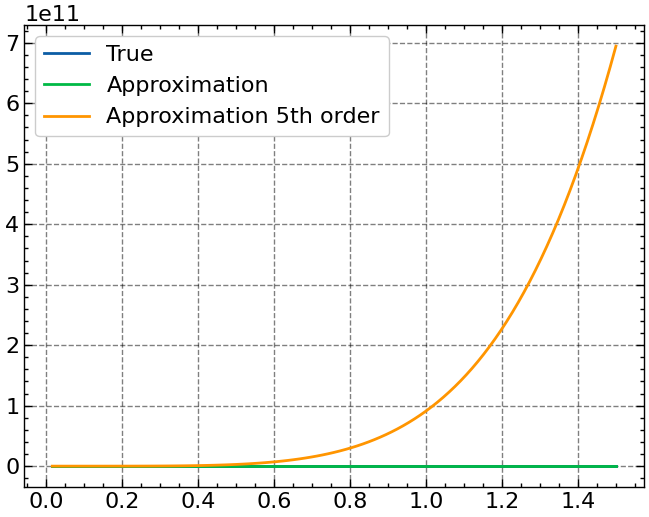

In [105]:
my_cosmo = cosmo.wCDM(H0=70, Om0=0.3, Ode0=0.7)

zs = np.linspace(0.001, 1.5, 100)
zs = zs[1:] # We don't want z = 0
dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value
plt.plot(zs, dls_true, label='True')
plt.plot(zs, z_series5(zs, q0=-0.55, j0=1, s0=-0.35,l0=3.1,H0=70), label='Approximation')
plt.plot(zs,z_series_5(zs,70,-0.55,1,-0.35,3.1), label='Approximation 5th order')
plt.legend()

In [108]:
c0=3.11
k=0
a0=1
H0=70
s0=-0.35
q0=-0.55
j0=1
l0=3.11


term4 = (1/120) * (10 * q0**2 - j0 * (105 * q0 + 27) - c0 + 105 * q0**4 + 165 * q0**3 + 81 * q0**2 - 15 * q0 * s0 + 6 * q0 - 11 * s0 - 6 + (5 * k/(a0**2 * H0**2)) * (2 * j0 - 9 * q0**2 - 8 * q0 - 1) + 1/(a0**4 * H0**4)) 
term3 = (1/24) * ((6 * q0 + 2) * k/(a0**2 * H0**2) + 5 * j0 * (2 * q0 + 1) - 15 * q0**3 - 15 * q0**2 - 2 * q0 + s0 + 2) 
a3 = 1.0/12.0 + 5 * j0 / 24.0 - q0/12.0 + 5.0*j0*q0/12.0  -5.0 * q0**2.0 / 8.0  -5.0 * q0**3.0 / 8.0 + s0/24.0


a4 = - 1.0/20.0 -9.0*j0/40+(j0**2)/12-l0/120+q0/20-(11*j0*q0)/12+27*q0**2/40-(7*j0*q0**2)/8+11*(q0**3)/8+(7*q0**4)/8-(11*s0)/120-q0*s0/8
print(term3,a3)

0.008671874999999996 0.008671875000000042


In [109]:
def chi_square_z(theta, z, data,func):
    
    diff = func(z, *theta) - data
    return np.sum(diff*diff)

func_array=[eval(f'z_series_{i}') for i in range(1,6)]
N=10    
ZMAX=2   #highest redshift to which we need to go
z_max_array=np.linspace(0.1,ZMAX,N)  #creates an array from 0.1 to ZMAX with N elements
X,Y=np.meshgrid(func_array,z_max_array)  #creates an square array with every possible combination of function and ZMAX
x1=np.reshape(X,(1,5*N))[0]## flattening the square matrices
y1=np.reshape(Y,(1,5*N))[0] 
priors = {
    'z_series_1': [70],
    'z_series_2': [70, -0.55],
    'z_series_3': [70, -0.55, 1],
    'z_series_4': [70, -0.55, 1, -0.35],
    'z_series_5': [70, -0.55, 1, -0.35, -3.11]
    
} #setting priors for every function

In [111]:
##initializing the values for the simulations

Ok = 0.0
w = -1.0
sim_num=[]
res=[]   #creating  empty arrays to append results
stat=[]
func_name_array=[]

my_cosmo = cosmo.wCDM(H0=70, Om0=0.3, Ode0=1.0-0.3-Ok)
for func,z_max in list(zip(x1,y1)):
        zs = np.linspace(0.00, z_max, 100)  
        func_name = func.__name__ ##extracting function name 
        zs = zs[1:] # We don't want z = 0
        initial_priors = priors[func_name]  #getting corresponding prior
        dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value ##getting true luminosity distance
        result = minimize(chi_square_z, initial_priors,args=(zs, dls_true,func), method='L-BFGS-B', options={'maxiter':950000})
        
        res.append(result.x)    ##appending results in the emtpy array
        stat.append(result.success)  ## seeing if i get succes in minimization
        #func_name=func_name_array.append(*[i.__name__ for i in np.array(list(zip(x1,y1)))[:,0]])
        sim_num.append(np.ones(100)*n)

func_name=[i.__name__ for i in np.array(list(zip(x1,y1)))[:,0]]
dct={'func':func_name,'zmax':np.array(list(zip(x1,y1)))[:,1],'Output':res,"success":stat}

In [124]:
# to be added later for n simuations and then taking an average
'''##initializing the values for the simulations
num_sim=10 # number of simulations 

H0 =  np.random.uniform(60,80,num_sim)
Om = np.random.uniform(0,0.5,num_sim)
Ok = 0.0
w = -1.0
sim_num=[]
res=[]   #creating  empty arrays to append results
stat=[]
func_name_array=[]
for n in tqdm(range(num_sim)):
    my_cosmo = cosmo.wCDM(H0=H0[n], Om0=Om[n], Ode0=1.0-Om[n]-Ok)
    for func,z_max in list(zip(x1,y1)):
        zs = np.linspace(0.00, z_max, 100)  
        func_name = func.__name__ ##extracting function name 
        zs = zs[1:] # We don't want z = 0
        initial_priors = priors[func_name]  #getting corresponding prior
    
        dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value ##getting true luminosity distance
        #print(func_name,z_max)
        result = minimize(chi_square_z, initial_priors,args=(zs, dls_true,func), method='L-BFGS-B', options={'maxiter':950000})
        res.append(result.x)    ##appending results in the emtpy array
        stat.append(result.success)  ## seeing if i get succes in minimization
        #func_name=func_name_array.append(*[i.__name__ for i in np.array(list(zip(x1,y1)))[:,0]])
        sim_num.append(np.ones(100)*n)

dct={'# simuation':sim_num,'zmax':np.array(list(zip(x1,y1)))[:,1],'Output':res,"success":stat}'''


'##initializing the values for the simulations\nnum_sim=10 # number of simulations \n\nH0 =  np.random.uniform(60,80,num_sim)\nOm = np.random.uniform(0,0.5,num_sim)\nOk = 0.0\nw = -1.0\nsim_num=[]\nres=[]   #creating  empty arrays to append results\nstat=[]\nfunc_name_array=[]\nfor n in tqdm(range(num_sim)):\n    my_cosmo = cosmo.wCDM(H0=H0[n], Om0=Om[n], Ode0=1.0-Om[n]-Ok)\n    for func,z_max in list(zip(x1,y1)):\n        zs = np.linspace(0.00, z_max, 100)  \n        func_name = func.__name__ ##extracting function name \n        zs = zs[1:] # We don\'t want z = 0\n        initial_priors = priors[func_name]  #getting corresponding prior\n    \n        dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value ##getting true luminosity distance\n        #print(func_name,z_max)\n        result = minimize(chi_square_z, initial_priors,args=(zs, dls_true,func), method=\'L-BFGS-B\', options={\'maxiter\':950000})\n        res.append(result.x)    ##appending results in the emtpy array\n      

In [114]:
q0_ar

array([[-0.47542875, -0.54959753, -0.55006148, -0.54926167],
       [-0.31508532, -0.54235909, -0.55162801, -0.5383256 ],
       [-0.16044075, -0.5210201 , -0.55503145, -0.5515783 ],
       [-0.01920201, -0.48381154, -0.55786598, -0.55516987],
       [ 0.10529199, -0.4327746 , -0.55698846, -0.55606501],
       [ 0.21272461, -0.37164199, -0.55001719, -0.55697506],
       [ 0.30440406, -0.30435249, -0.53585569, -0.55906367],
       [ 0.38229049, -0.2343035 , -0.51449643, -0.55740167],
       [ 0.44844718, -0.16409746, -0.4866297 , -0.54812258],
       [ 0.50478083, -0.09557103, -0.45333831, -0.51900386]])

In [113]:
df=pd.DataFrame(dct) #getting a dataframe of the results ,function name and success to do easy visualization 
##print(df) to see how df looks like 
#getting the H0 results 
H0_ar=[]
for i in df.Output:
    H0_ar.append(i[0])

q0_ar=[]
ix=0
for j in df.Output :
    if df.func.iloc[ix]!='z_series_1':
        q0_ar.append(j[1])
    ix+=1

#getting the j0 results 

j0_ar=[]
ix=0
for k in df.Output :
    if df.func.iloc[ix]!='z_series_1' and df.func.iloc[ix]!='z_series_2':
        j0_ar.append(k[2])
    ix+=1

    
##getting the error from true values 
H0_ar=np.reshape(H0_ar,(N,5)) ##first reshaping the arrays to get Nx5 matrix since we want our results in a matrix form
H0_err=abs((73.8-H0_ar)/73.8)*100
H0_err=np.flip(H0_err, axis=0)  ##flipping the array due to visualization
q0_ar=np.reshape(q0_ar,(N,4))
q0_err=abs((0.55+q0_ar)/0.55)*100
q0_err=np.flip(q0_err, axis=0)

j0_ar=np.reshape(j0_ar,(N,3))
j0_err=abs((1-j0_ar)/1)*100
j0_err=np.flip(j0_err, axis=0)


<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Animesh\AppData\Local\Temp\ipykernel_3372\3307682648.py:10: SyntaxWarning: invalid escape sequence '\m'
  x_labels = ['$\mathcal{O}(1)$', '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$']
C:\Users\Animesh\AppData\Local\Temp\ipykernel_3372\3307682648.py:10: SyntaxWarning: invalid escape sequence '\m'
  x_labels = ['$\mathcal{O}(1)$', '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$']
C:\Users\Animesh\AppData\Local\Temp\ip

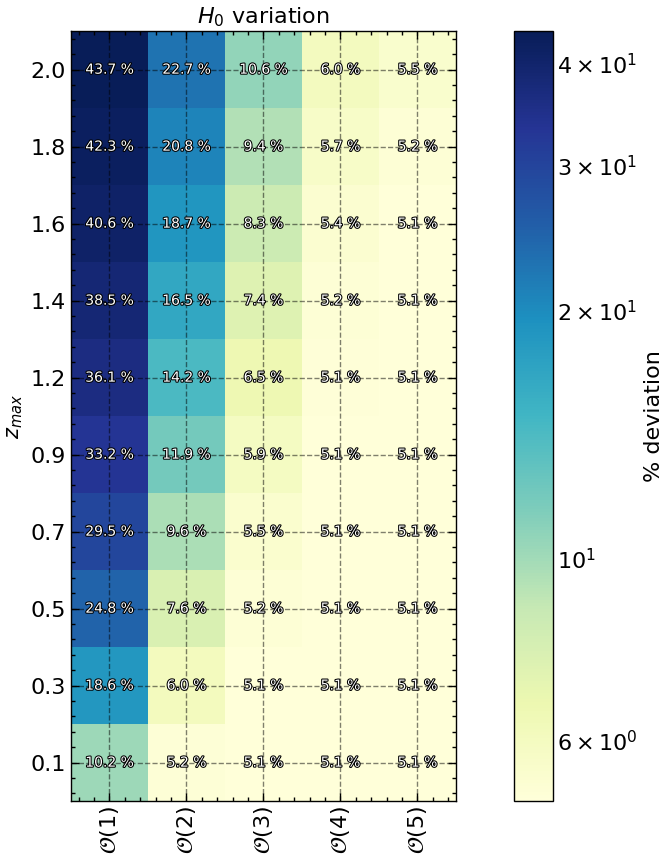

In [119]:
plt.figure(figsize=(15,10))
plt.title('$H_0$ variation')
norm = mcolors.LogNorm(vmin=H0_err[H0_err > 0].min(), vmax=H0_err.max()) #W#creating color bar for log plot 

plt.imshow(H0_err,norm=norm,cmap=color_map) ##matrix plot 
y_ticks=[i for i in range(int(N))]
y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
x_ticks = [0, 1, 2, 3,4] 
plt.ylabel('$z_{max}$',fontsize=15)
x_labels = ['$\mathcal{O}(1)$', '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$'] 
plt.xticks(x_ticks, x_labels, rotation ='vertical') 
plt.yticks(y_ticks, y_labels) 
plt.colorbar(label='% deviation')
## for annotating on the plot
for i in range(H0_err.shape[0]):
    for j in range(H0_err.shape[1]):
        text = plt.text(j, i, f'{H0_err[i, j]:.1f} %',
                       ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

plt.show()


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Animesh\AppData\Local\Temp\ipykernel_3372\3217927346.py:12: SyntaxWarning: invalid escape sequence '\m'
  x_labels = [ '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$']
C:\Users\Animesh\AppData\Local\Temp\ipykernel_3372\3217927346.py:12: SyntaxWarning: invalid escape sequence '\m'
  x_labels = [ '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$']
C:\Users\Animesh\AppData\Local\Temp\ipykernel_3372\3217927346.py:12: SyntaxWarning: invalid escape sequence '\m'
  x_labels = [ '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal

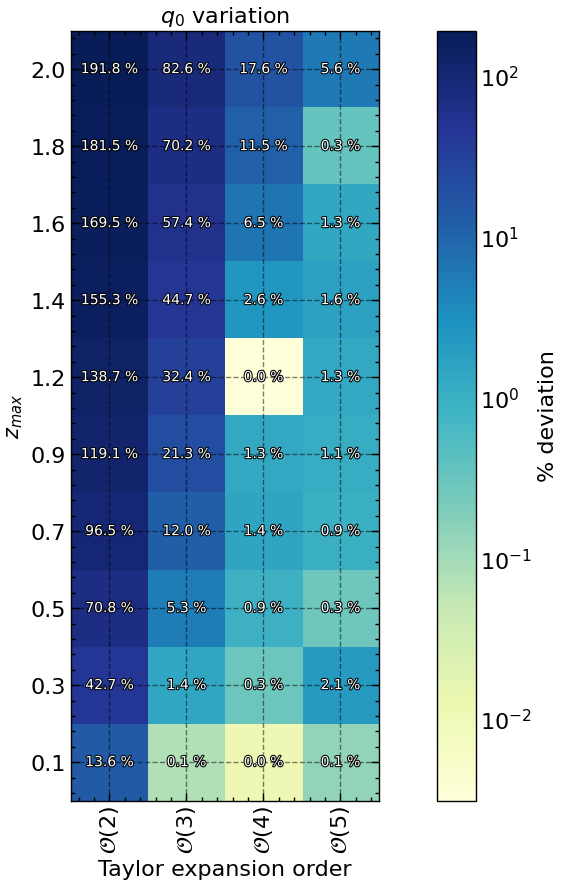

In [116]:

## q0_plot 
plt.figure(figsize=(15,10))
plt.title('$q_0$ variation')
norm = mcolors.LogNorm(vmin=q0_err[q0_err > 0].min(), vmax=q0_err.max())

plt.imshow(q0_err,cmap=color_map,norm=norm)
y_ticks=[i for i in range(int(N))]
y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
x_ticks = [0, 1, 2, 3] 
plt.ylabel('$z_{max}$',fontsize=15)
plt.xlabel('Taylor expansion order')
x_labels = [ '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$'] 
plt.xticks(x_ticks, x_labels, rotation ='vertical') 
plt.yticks(y_ticks, y_labels) 
for i in range(q0_err.shape[0]):
    for j in range(q0_err.shape[1]):
        text = plt.text(j, i, f'{q0_err[i, j]:.1f} %',
                       ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

#v = np.linspace(0, 100, 10, endpoint=True)

plt.colorbar(label='% deviation')
plt.show()


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Animesh\AppData\Local\Temp\ipykernel_3372\4110190224.py:12: SyntaxWarning: invalid escape sequence '\m'
  x_labels = [  '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$']
C:\Users\Animesh\AppData\Local\Temp\ipykernel_3372\4110190224.py:12: SyntaxWarning: invalid escape sequence '\m'
  x_labels = [  '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$']
C:\Users\Animesh\AppData\Local\Temp\ipykernel_3372\4110190224.py:12: SyntaxWarning: invalid escape sequence '\m'
  x_labels = [  '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$']


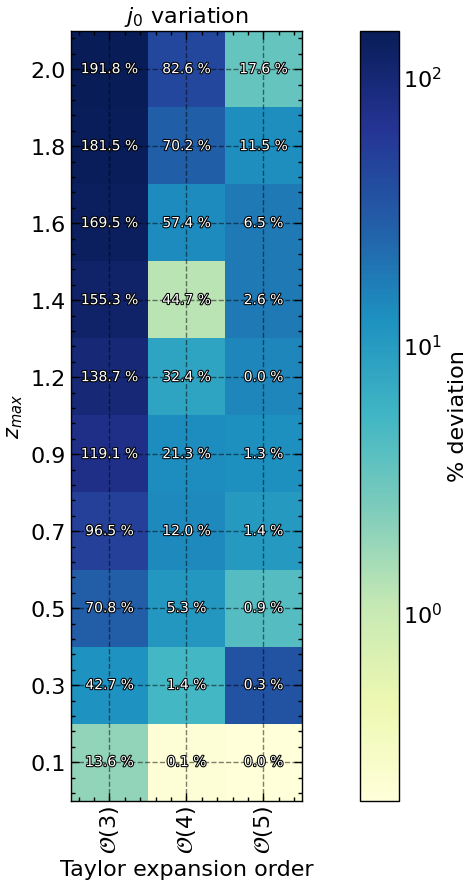

In [122]:

## q0_plot 
plt.figure(figsize=(15,10))
plt.title('$j_0$ variation')
norm = mcolors.LogNorm(vmin=j0_err[j0_err > 0].min(), vmax=j0_err.max())

plt.imshow(j0_err,cmap=color_map,norm=norm)
y_ticks=[i for i in range(int(N))]
y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
x_ticks = [0, 1, 2] 
plt.ylabel('$z_{max}$',fontsize=15)
plt.xlabel('Taylor expansion order')
x_labels = [  '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$'] 
plt.xticks(x_ticks, x_labels, rotation ='vertical') 
plt.yticks(y_ticks, y_labels) 
for i in range(j0_err.shape[0]):
    for j in range(j0_err.shape[1]):
        text = plt.text(j, i, f'{q0_err[i, j]:.1f} %',
                       ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

#v = np.linspace(0, 100, 10, endpoint=True)

plt.colorbar(label='% deviation')
plt.show()


array([[ 0.9809687 ,  0.99783845,  0.99800788],
       [ 0.8806145 ,  1.05177821,  0.64992657],
       [ 0.7098243 ,  1.10661915,  1.04118762],
       [ 0.4932148 ,  1.13941729,  1.10142427],
       [ 0.26049815,  1.13227816,  1.12655913],
       [ 0.03835616,  1.08031922,  1.14604541],
       [-0.15420875,  0.98796099,  1.18153489],
       [-0.30674926,  0.86446491,  1.18226375],
       [-0.41595718,  0.72068128,  1.13077166],
       [-0.48342717,  0.56721774,  0.96688268]])